# 13.3.2 过去窗口与预警误差

## 学习目标与先修知识

仅用过去样本计算波动和指定时间间隔的相关，评估误报（false alarm）与漏报（missed event）。

先修：13.3.1 局部恢复；5.2 方差（variance）、6.1 采样（sampling）、6.5 独立验证。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

方差或自相关上升，经常被用作变慢的信号。若只是噪声强度变大、采样间隔改变，或者用到了未来数据，同样的图会怎样误导？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

稳定 AR(1) 的一步条件式为 x_next=ρx+σε；比较保持 ρ 不变而放大 σ，与保持 σ 不变而提高 ρ 的预测。

In [2]:
for rho,sigma in [(.7,.2),(.7,.5),(.95,.2)]:
    print('ρ',rho,'σ',sigma,'平稳方差',round(sigma**2/(1-rho**2),4),'一步相关',rho)

ρ 0.7 σ 0.2 平稳方差 0.0784 一步相关 0.7
ρ 0.7 σ 0.5 平稳方差 0.4902 一步相关 0.7
ρ 0.95 σ 0.2 平稳方差 0.4103 一步相关 0.95


## 模型假设

本节 AR(1) 对照使用零均值单位方差、跨时刻独立的固定创新序列，|ρ|<1；前段与后段只改变 ρ 或 σ 之一。平稳矩公式只适用于各固定参数（parameter）的平稳段，不能跨突变直接套用。窗口指标只用预测时刻及其以前的样本；采样间隔保持相同，若改变须用固定物理滞后（fixed physical lag）重设 lag。

## 数学解释与推导

固定参数 AR(1) $x_{t+1}=\rho x_t+\sigma\epsilon_t$ 在 $|\rho|<1$ 时有平稳方差 $\sigma^2/(1-\rho^2)$，一步自相关为 $\rho$。因此 $\rho\uparrow1$ 可使两者上升，但只增大 $\sigma$ 也能提高方差而不改变模型（model）恢复参数。过去窗口 $W_t=(x_{t-w+1},\ldots,x_t)$ 的总体方差为 $w^{-1}\sum(x-\bar x)^2$；滞后（lag）相关用配对片段各自中心化。事件（event）级检出定义为事件前 $h$ 步内至少一次报警；未对应事件的报警为误报，无报警覆盖的事件为漏报。阈值必须在独立评价之前固定。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def ar1_series(rhos, sigmas, innovations):
    """Time-varying AR(1) under a supplied standard-innovation sequence."""
    values = [0.0]
    for rho, sigma, shock in zip(rhos, sigmas, innovations):
        values.append(rho * values[-1] + sigma * shock)
    return values


def past_window_stats(values, time_index, window, lag):
    """Population variance and fixed-sample-lag Pearson correlation, past only."""
    if time_index + 1 < window or lag < 1 or lag >= window:
        return [None, None]
    tail = values[time_index - window + 1:time_index + 1]
    mean = sum(tail) / window
    variance = sum((value - mean) ** 2 for value in tail) / window
    earlier, later = tail[:-lag], tail[lag:]
    mean_a = sum(earlier) / len(earlier)
    mean_b = sum(later) / len(later)
    centered_a = [value - mean_a for value in earlier]
    centered_b = [value - mean_b for value in later]
    denominator = math.sqrt(sum(x*x for x in centered_a) * sum(y*y for y in centered_b))
    correlation = sum(x*y for x, y in zip(centered_a, centered_b)) / denominator if denominator else None
    return [variance, correlation]


def alert_counts(alert_times, event_times, horizon):
    """Event-level detections, false alert times, missed events; no true-negative count."""
    alerts, events = set(alert_times), set(event_times)
    detected = sum(any(event - horizon <= alert < event for alert in alerts) for event in events)
    false_alerts = sum(not any(alert < event <= alert + horizon for event in events) for alert in alerts)
    return [detected, false_alerts, len(events) - detected]

## 对照实验

对两条共享创新序列的240步轨迹（trajectory）比较：A 在中点提高 ρ，B 只增大噪声 σ。过去40样本窗口逐步计算方差。

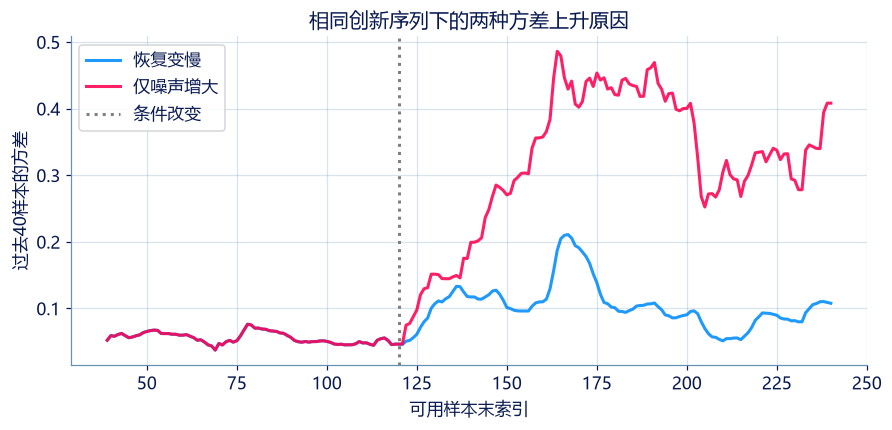

事件计数示例： [1, 2, 1]


In [4]:
rng=np.random.default_rng(130302);shocks=rng.standard_normal(240)
rhos_slow=[.7]*120+[.95]*120;sigmas_slow=[.2]*240
rhos_noise=[.7]*240;sigmas_noise=[.2]*120+[.5]*120
paths={'恢复变慢':ar1_series(rhos_slow,sigmas_slow,shocks),
       '仅噪声增大':ar1_series(rhos_noise,sigmas_noise,shocks)}
fig,ax=plt.subplots(figsize=(8,3.8))
for name,color in zip(paths,[BLUE,PINK]):
    series=paths[name]
    variance=[past_window_stats(series,t,40,1)[0] for t in range(39,len(series))]
    ax.plot(range(39,len(series)),variance,label=name,color=color,alpha=.88)
ax.axvline(120,color='gray',ls=':',label='条件改变')
ax.set(xlabel='可用样本末索引',ylabel='过去40样本的方差',title='相同创新序列下的两种方差上升原因')
ax.legend();ax.grid(alpha=.25);plt.show()
print('事件计数示例：',alert_counts([2,4,8],[5,12],2))

## 结果解释

两种不同机制都可能让窗口方差上升；因此波动增加不是转变的充分证据。两段的 ρ 都小于 1，系统仍在稳定区间。若要评价预警效果，需再用带有真实转变标签的独立数据计算误报、漏报和提前量。

### 独立核对

未来样本改成极端值时，当前指标不变；手算小表验证事件级检出与报警级误报。

In [5]:
base=[0.,1.,2.,3.];future=base+[9999.]
assert past_window_stats(base,3,4,1)==past_window_stats(future,3,4,1)
np.testing.assert_allclose(past_window_stats(base,3,4,1),[1.25,1.])
assert alert_counts([2,4,8],[5,12],2)==[1,2,1]
print('无未来泄漏、方差/相关与误报漏报核对通过。')

无未来泄漏、方差/相关与误报漏报核对通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/13-03-%E6%89%B0%E5%8A%A8%E3%80%81%E6%81%A2%E5%A4%8D%E4%B8%8E%E6%97%A9%E6%9C%9F%E9%A2%84%E8%AD%A6/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：只用过去窗口计算指标

在 time_index 时仅使用含当前样本在内的过去 window 个观测（observation），返回该窗总体方差（variance）和相隔 lag 个样本的 Pearson 相关。窗不足或任一配对序列恒定时，相关项返回 None。

**函数与代码模板**

```python
def solve(
    values: list[float],
    time_index: int,
    window: int,
    lag: int,
) -> list[float | None]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 按时间排列的观测序列。 | 观测单位 |
| `time_index` | `int` | 当前可用观测的末索引。 | 样本编号 |
| `window` | `int` | 过去窗口样本数。 | 样本 |
| `lag` | `int` | 配对样本的索引差，介于1和window-1。 | 样本 |

**返回值**

直接返回 indicators（list[float | None]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `indicators` | <code>list[float &#124; None]</code> | 总体方差、指定滞后（lag）的 Pearson 相关；无法定义时为 None。 | 依输入单位²、无量纲 |

**计算规则**

配对片段各自中心化；不能读取 time_index 之后的样本。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| values | 按时间排列的观测序列。 | [0.0, 1.0, 2.0, 3.0, 99.0] | 观测单位 |
| time_index | 当前可用观测的末索引。 | 3 | 样本编号 |
| window | 过去窗口样本数。 | 4 | 样本 |
| lag | 配对样本的索引差，介于1和window-1。 | 1 | 样本 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
values = [0.0, 1.0, 2.0, 3.0, 99.0]
time_index = 3
window = 4
lag = 1

result = solve(values, time_index, window, lag)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| indicators | 总体方差、指定滞后（lag）的 Pearson 相关；无法定义时为 None。 | [1.25, 1.0] | 依输入单位²、无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.25, 1.0]
```

**样例解释**

第一个样例末尾的99是未来数据，必须忽略；恒定窗的相关系数（correlation coefficient）分母为0，返回 None。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：只用过去窗口计算指标](http://127.0.0.1:8000/chapters/13-03-%E6%89%B0%E5%8A%A8%E3%80%81%E6%81%A2%E5%A4%8D%E4%B8%8E%E6%97%A9%E6%9C%9F%E9%A2%84%E8%AD%A6/practice/?question=p13-past-window-indicators)

### 第 2 题 · 单项选择题：慢化指标的条件

稳定 AR(1) x_{t+1}=rho*x_t+epsilon_t，噪声方差（variance）固定且 |rho|<1。rho 从0.5升至0.9时哪项成立？

- **A.** 平稳方差 sigma²/(1-rho²) 增大，固定一步相关也增大。
- **B.** 方差必减小，因为恢复慢。
- **C.** 任何真实系统都将在同一时间转变。
- **D.** rho 是临床效用而非动态参数（parameter）。

[作答：慢化指标的条件](http://127.0.0.1:8000/chapters/13-03-%E6%89%B0%E5%8A%A8%E3%80%81%E6%81%A2%E5%A4%8D%E4%B8%8E%E6%97%A9%E6%9C%9F%E9%A2%84%E8%AD%A6/practice/?question=p13-ar1-warning-condition)

### 第 3 题 · 单项选择题：没有转变也能升方差

在 AR(1) 的 rho 保持0.7时，仅过程噪声（process noise）标准差（standard deviation）从0.2升至0.5。方差（variance）预警阈值触发可以说明什么？

- **A.** 可能是噪声改变造成的误报（false alarm），应检查独立对照和事件（event）标签。
- **B.** 必然证明恢复率接近零。
- **C.** 必然证明跨过吸引域（basin of attraction）边界。
- **D.** 可以用未来样本重新计算过去时刻并仍称为实时预警。

[作答：没有转变也能升方差](http://127.0.0.1:8000/chapters/13-03-%E6%89%B0%E5%8A%A8%E3%80%81%E6%81%A2%E5%A4%8D%E4%B8%8E%E6%97%A9%E6%9C%9F%E9%A2%84%E8%AD%A6/practice/?question=p13-noise-control)

### 第 4 题 · 单项选择题：固定物理滞后

观测（observation）采样（sampling）间隔从1 T缩短到0.5 T。为了比较同一个1 T的自相关，应如何选择样本滞后（lag）？

- **A.** 旧数据 lag=1，新数据 lag=2。
- **B.** 两个序列始终 lag=1。
- **C.** 只比较样本数，不管采样间隔。
- **D.** 新数据使用 lag=0。

[作答：固定物理滞后](http://127.0.0.1:8000/chapters/13-03-%E6%89%B0%E5%8A%A8%E3%80%81%E6%81%A2%E5%A4%8D%E4%B8%8E%E6%97%A9%E6%9C%9F%E9%A2%84%E8%AD%A6/practice/?question=p13-lag-physical-time)

**进一步阅读**

[Scheffer 等（2009）](https://www.nature.com/articles/nature08227)是预警指标的研究起点；这里特设噪声对照与事先固定的事件窗口。